In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  p

In [7]:
print(df.columns.tolist())

['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [8]:
print("Missing values:")
print(df.isnull().sum())

print("Total missing values:", df.isnull().sum().sum())

Missing values:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64
Total missing values: 0


In [9]:
print("Number of instances:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of instances: 569
Number of columns: 32


In [10]:
df.columns

print(df["diagnosis"].value_counts())

B    357
M    212
Name: diagnosis, dtype: int64


In [11]:
df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

In [12]:
df = df.drop("id", axis=1)

print(df.columns.tolist())

['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [13]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [14]:
print("Number of features:", X.shape[1])

print("\nFeature names:")
for i, column in enumerate(X.columns, 1):
    print(i, column)

Number of features: 30

Feature names:
1 radius_mean
2 texture_mean
3 perimeter_mean
4 area_mean
5 smoothness_mean
6 compactness_mean
7 concavity_mean
8 concave points_mean
9 symmetry_mean
10 fractal_dimension_mean
11 radius_se
12 texture_se
13 perimeter_se
14 area_se
15 smoothness_se
16 compactness_se
17 concavity_se
18 concave points_se
19 symmetry_se
20 fractal_dimension_se
21 radius_worst
22 texture_worst
23 perimeter_worst
24 area_worst
25 smoothness_worst
26 compactness_worst
27 concavity_worst
28 concave points_worst
29 symmetry_worst
30 fractal_dimension_worst


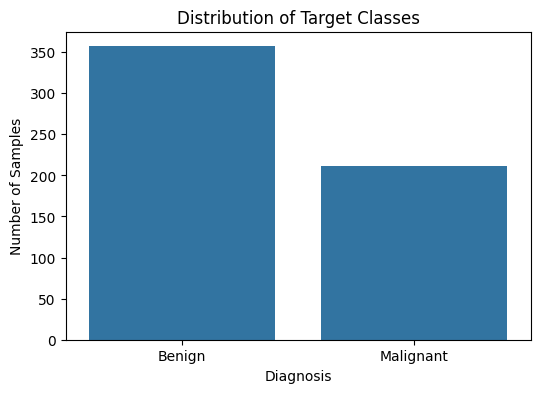

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x=y
)

plt.title("Distribution of Target Classes")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.xticks(
    [0, 1],
    ["Benign", "Malignant"]
)

plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [17]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "Gaussian Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [18]:
for name, model in models.items():

    model.fit(X_train, y_train)

    print(name, "trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
K-Nearest Neighbors trained successfully
Gaussian Naive Bayes trained successfully
Random Forest trained successfully


In [19]:
predictions = {}
probabilities = {}

for name, model in models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

print("Predictions generated successfully.")

Predictions generated successfully.


In [20]:
results = []

for name in models.keys():

    y_pred = predictions[name]
    y_prob = probabilities[name]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "AUC Score": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC Score": mcc
    })

In [21]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,AUC Score,Precision,Recall,F1 Score,MCC Score
0,Logistic Regression,0.964912,0.996032,0.975000,0.928571,0.951220,0.924518
1,Decision Tree,0.929825,0.924603,0.904762,0.904762,0.904762,0.849206
2,K-Nearest Neighbors,0.956140,0.982308,0.974359,0.904762,0.938272,0.905824
3,Gaussian Naive Bayes,0.938596,0.993386,1.000000,0.833333,0.909091,0.871489
4,Random Forest,0.973684,0.992890,1.000000,0.928571,0.962963,0.944155


In [22]:
for name in models.keys():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=[
                "Benign",
                "Malignant"
            ]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Decision Tree
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        72
   Malignant       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

K-Nearest Neighbors
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0

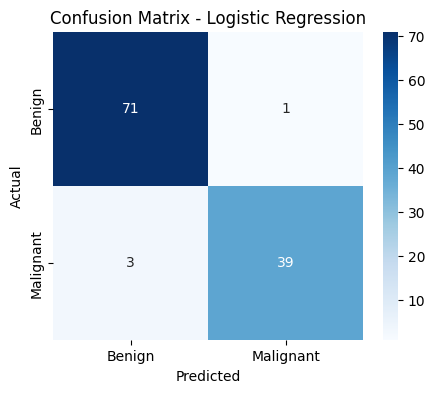

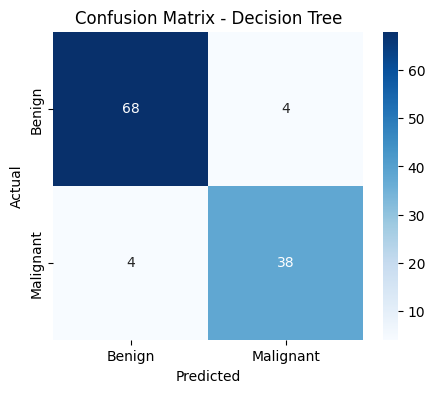

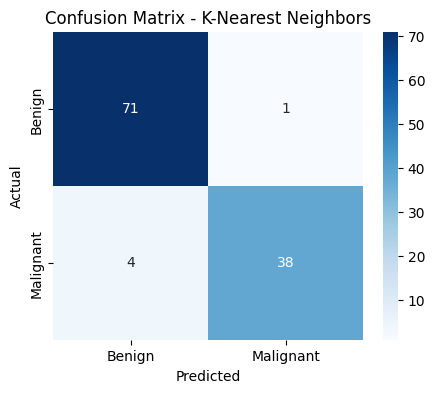

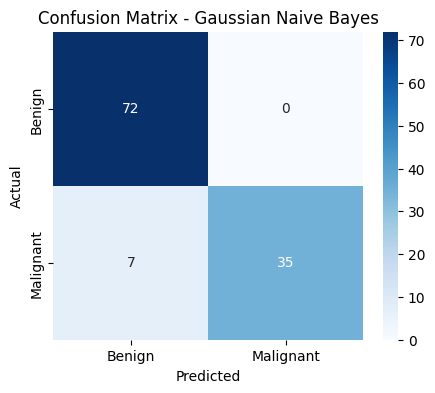

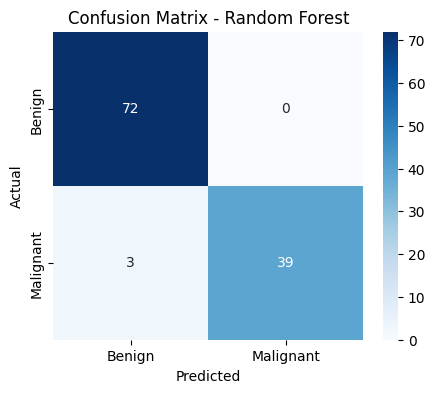

In [23]:
for name in models.keys():

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Benign",
            "Malignant"
        ],
        yticklabels=[
            "Benign",
            "Malignant"
        ]
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

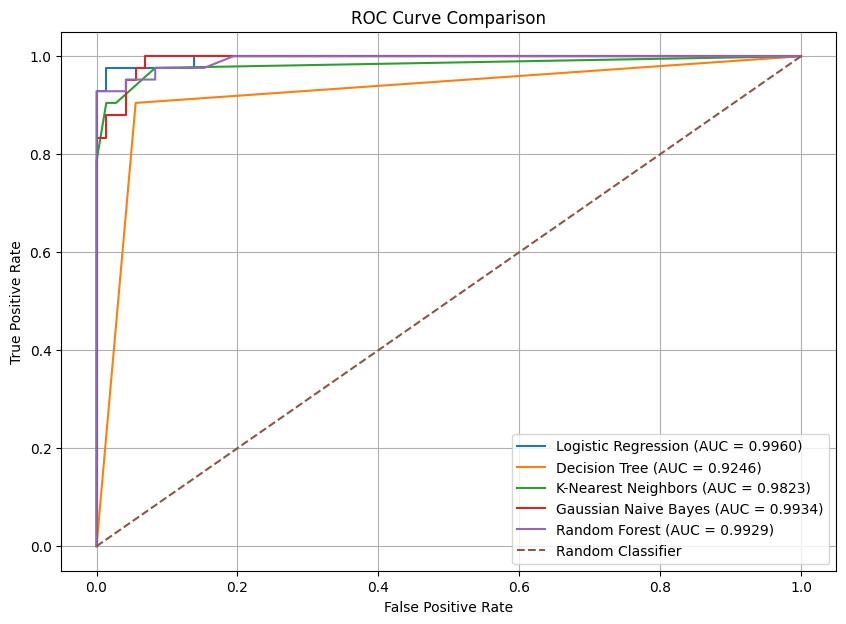

In [24]:
plt.figure(figsize=(10, 7))

for name in models.keys():

    y_prob = probabilities[name]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid()

plt.show()

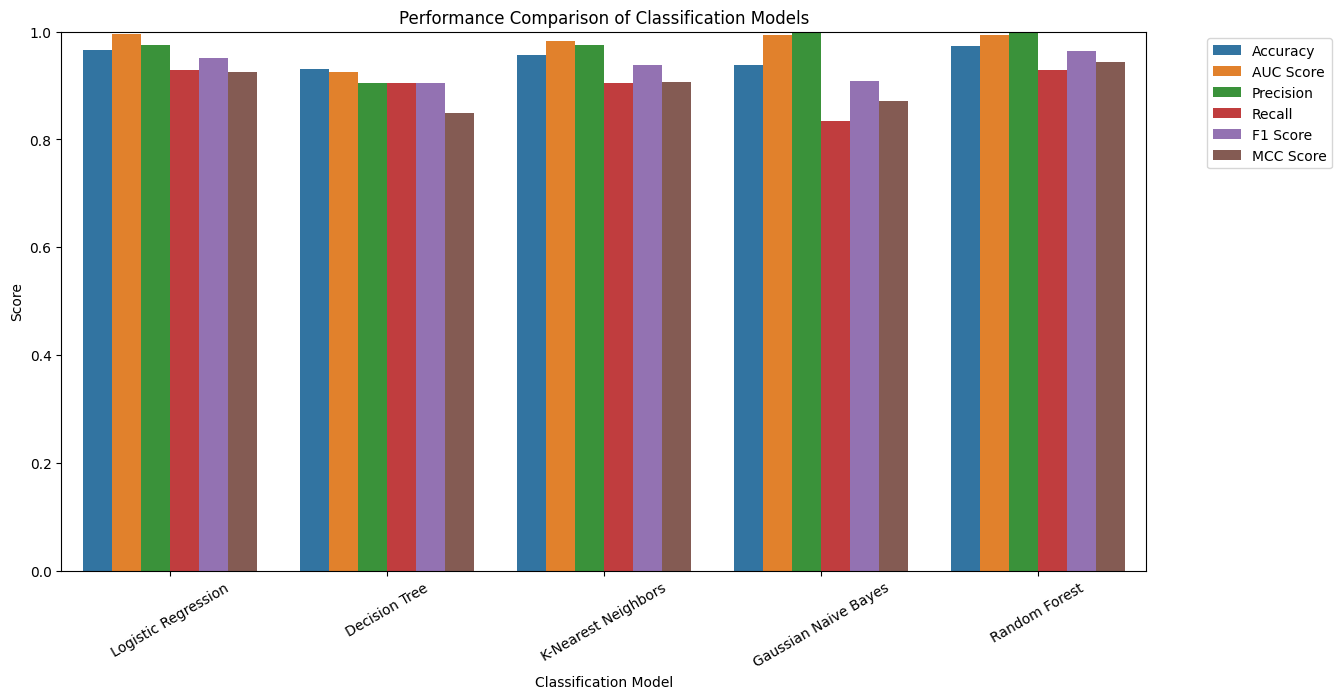

In [25]:
metric_columns = [
    "Accuracy",
    "AUC Score",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC Score"
]

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metric_columns,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Performance Comparison of Classification Models"
)

plt.xlabel("Classification Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=30)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

In [26]:
for metric in metric_columns:

    index = results_df[metric].idxmax()

    model = results_df.loc[index, "Model"]

    score = results_df.loc[index, metric]

    print(
        f"Best {metric}: {model} "
        f"({score:.4f})"
    )

Best Accuracy: Random Forest (0.9737)
Best AUC Score: Logistic Regression (0.9960)
Best Precision: Gaussian Naive Bayes (1.0000)
Best Recall: Logistic Regression (0.9286)
Best F1 Score: Random Forest (0.9630)
Best MCC Score: Random Forest (0.9442)


results_df.round(4).to_csv(
    "data.csv",
    index=False
)

print("Results saved successfully.")

In [27]:
import joblib
import os

In [28]:
os.makedirs("model", exist_ok=True)

print("model folder created")

model folder created


In [29]:
joblib.dump(
    models["Logistic Regression"],
    "model/logistic_regression.pkl"
)

joblib.dump(
    models["Decision Tree"],
    "model/decision_tree.pkl"
)

joblib.dump(
    models["K-Nearest Neighbors"],
    "model/knn.pkl"
)

joblib.dump(
    models["Gaussian Naive Bayes"],
    "model/naive_bayes.pkl"
)

joblib.dump(
    models["Random Forest"],
    "model/random_forest.pkl"
)

print("All 5 models saved successfully!")

All 5 models saved successfully!


In [30]:
test_data = X_test.copy()

test_data["diagnosis"] = y_test

test_data.to_csv(
    "test_data.csv",
    index=False
)

print("test_data.csv created successfully!")
print("Shape:", test_data.shape)

test_data.csv created successfully!
Shape: (114, 31)
